# M1 Assignment: Classical ML Essentials
### Thrive Plus · Advanced ML & AI

---

**Group Number:** ____________6_______________  
**Group Members (those who participated)**: ____________Lukeman Abubakar_______________  
**Date:** ____________May 19,2026_______________  
**Submission:** Push this notebook to GitHub (use the account of the group rep for submission but all group members shoudl push the assignment to their github) and submit the repo link via the course portal.

---

## Instructions

- Run every cell **in order**, top to bottom.  
- Replace every `# YOUR CODE HERE` with working code.  
- Fill in every `> **Your answer:**` prompt with your own words.  
- **Bonus** tasks are optional — attempt them but you wont lose marks for not doing them.  
- If a cell breaks, read the error message from the **bottom up**. The last line is almost always the most useful.

---

## 0. Problem Scoping

Read this section carefully before writing any code.

---

### The Business Context

A Portuguese bank ran a series of phone-based marketing campaigns to get customers to subscribe to a **term deposit** — a savings product where money is locked in for a fixed period in exchange for a guaranteed interest rate.

Calling every customer is expensive. A campaign team has limited agents, limited hours, and a list of thousands of contacts. They need to know: **who is actually likely to say yes?**

Your job is to build a model that scores each customer by their likelihood of subscribing. The campaign team will prioritise the customers with the highest scores.

---

### The Dataset

**Source:** UCI Machine Learning Repository — [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
**Kaggle mirror:** https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset  
**Paper:** Moro et al., 2014 — *A Data-Driven Approach to Predict the Success of Bank Telemarketing*

The dataset contains **45,211 rows** and **17 columns** — one row per customer contact. The columns describe:

| Group | Columns |
|---|---|
| **Client info** | age, job, marital status, education, credit default, housing loan, personal loan |
| **Last contact** | contact type, month, day of week, duration |
| **Campaign info** | number of contacts this campaign, days since last campaign, contacts previous campaign, outcome of previous campaign |
| **Target** | `y` — did the client subscribe? (`yes` / `no`) |

---

### Stakeholder Questions

Before you write a single line of code, answer these questions. Come back and revise them after you've explored the data.

**Q0.1 — What decision does this model support?**

> **Your answer:** *(Who uses the model output, and what do they do with it?)*
The model supports campaign prioritisation. The marketing/campaign team uses each customer’s predicted probability of subscribing to decide which customers agents should call first when time, staffing, and call capacity are limited.

**Q0.2 — What does a false positive cost the business?**  
*(The model says "will subscribe" but they don't.)*

> **Your answer:**
A false positive means the team spends effort calling someone who is unlikely to subscribe.

The cost is mainly wasted agent time, phone/contact cost, opportunity cost from not calling a better lead, and possible customer irritation from unnecessary outreach. It is bad, but usually not catastrophic unless call volume is very constrained or customer experience risk is high.

**Q0.3 — What does a false negative cost the business?**  
*(The model says "won't subscribe" but they would have.)*
A false negative means the team skips or deprioritises someone who actually would have subscribed.

The cost is lost revenue or deposits from a missed successful sale. It may also mean the campaign underperforms because good prospects were left uncontacted.

> **Your answer:**

**Q0.4 — Given your answers above, which metric should we prioritise: Precision or Recall? Why?**

> **Your answer:**
I would prioritise Precision, especially near the top of the ranked list.

Because the business has limited agents and can only call a subset of customers, the model is most useful if the people it identifies as high-priority are genuinely likely to subscribe. High precision means fewer wasted calls and better use of campaign capacity.

---

## 1. Setup

Run this cell first. It installs and imports everything you'll need.

In [ ]:
!pip -q install numpy pandas matplotlib seaborn scikit-learn

---
## 2. Load & Understand the Data

### 2.1 — Download the data

Download the file `bank-full.csv` from the Kaggle mirror linked in Section 0, or run the cell below.  
Once it's in your working directory, load it with pandas.

> **Note:** The file uses `;` as a separator, not `,`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

np.random.seed(42)
print("All imports successful.")

All imports successful.


In [ ]:
import numpy as np
import pandas as pd
import os

# Option A — download directly (works in Colab, may need adjustments locally)
# The original problem statement refers to `bank-full.csv`, which is in `bank.zip`

# Clean up any previous downloads to ensure a fresh start
!rm -f bank.zip bank-full.csv

# Removed -q from wget to see download progress/errors
# Added --no-check-certificate due to expired SSL certificate on the UCI server
!wget --no-check-certificate "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
!unzip -q bank.zip

# Verify files are present
!ls -l bank.zip bank-full.csv

# Option B — load from your working directory after manual download
df = pd.read_csv("bank-full.csv", sep=";")

print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

--2026-05-24 00:35:13--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
  Issued certificate has expired.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank.zip’

bank.zip                [  <=>               ] 565.47K  2.28MB/s    in 0.2s    

2026-05-24 00:35:14 (2.28 MB/s) - ‘bank.zip’ saved [579043]

replace bank-names.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: -rw-r--r-- 1 root root 4610348 Feb 14  2012 bank-full.csv
-rw-r--r-- 1 root root  579043 May 24 00:35 bank.zip
Loaded: 45,211 rows, 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


### 2.2 — First look

In [ ]:
# Run .info() to see column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# Run .describe() to see summary statistics for numeric columns
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


### 2.3 — Identify column types

Look at the output of `df.info()` above and fill in the lists below.  
You'll use these lists in the preprocessing step.

In [ ]:
# Fill in the lists below.
# Hint: look at the dtype column in df.info() output.
# Columns with dtype int64 or float64 are numeric.
# Columns with dtype object are categorical.

numeric_features = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"
    # YOUR CODE HERE — list the numeric column names as strings
    # e.g. "age", ...
]

categorical_features = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"
    # YOUR CODE HERE — list the categorical column names as strings
    # Don't include the target column "y"
]

# Quick check
print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)
print(f"\nTotal accounted for: {len(numeric_features) + len(categorical_features)} (should be {df.shape[1] - 1})")

Numeric features:     ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Total accounted for: 16 (should be 16)


### 2.4 — Check for missing values

This dataset doesn't use `NaN` for missing data. Look carefully at what comes back — something unusual may be hiding in the values.

In [ ]:
# Standard missing value check
print("NaN counts per column:")
print(df.isnull().sum())

NaN counts per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
# Now look at the unique values in the categorical columns
for col in categorical_features:
    print(f"{col:20s}: {df[col].unique()}")

job                 : ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital             : ['married' 'single' 'divorced']
education           : ['tertiary' 'secondary' 'unknown' 'primary']
default             : ['no' 'yes']
housing             : ['yes' 'no']
loan                : ['no' 'yes']
contact             : ['unknown' 'cellular' 'telephone']
month               : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome            : ['unknown' 'failure' 'other' 'success']


**Q2.4 — What did you find?**

> **Your answer:** *(Is there anything suspicious in the unique values above? What does it mean for preprocessing?)*
The standard NaN check shows no missing values, but the categorical unique values reveal that the dataset uses the string "unknown" to represent missing or unavailable information.

That is suspicious because "unknown" appears as a real category, especially in columns such as job, education, contact, and poutcome. So the data is not truly complete, even though df.isnull().sum() says there are no missing values.

---

### 2.5 — Target distribution

The target column is `y` — it contains the strings `"yes"` and `"no"`. We need to understand how balanced it is.

In [ ]:
# Compute and print the count and percentage of each class
counts = df["y"].value_counts()
rates  = df["y"].value_counts(normalize=True).round(4) * 100

print("Counts:")
print(counts)
print()
print("Percentage:")
print(rates)

Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


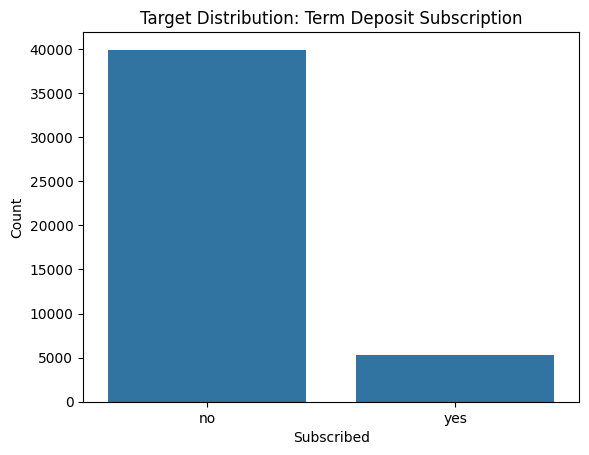

In [ ]:
# Plot the class distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x="y")
# Hint: sns.countplot — docs: https://seaborn.pydata.org/generated/seaborn.countplot.html
# x axis = "y", data = df



plt.title("Target Distribution: Term Deposit Subscription")
plt.ylabel("Count")
plt.xlabel("Subscribed")
plt.show()

In [ ]:
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    "count": target_counts,
    "percent": target_pct
})

**Q2.5 — What is the subscription rate? What problem does this create for model evaluation?**

> **Your answer:**
yes: 5,289 out of 45,211
subscription rate = 11.7%

That means the dataset is strongly imbalanced: most customers did not subscribe.

This creates a problem for model evaluation because accuracy can be misleading. A model that predicts "no" for everyone would be about 88.3% accurate, but it would find zero actual subscribers. So we should focus on metrics that reflect performance on the positive class, such as precision, recall, F1 score, ROC-AUC, PR-AUC, and especially precision/recall at the campaign’s call capacity.
---

## 3. Exploratory Data Analysis

### 3.1 — Choosing the right plot

Before you visualise, ask: *what data types are involved?*

| X column type | Y column type | Recommended plot |
|---|---|---|
| Categorical | None | `sns.countplot` |
| Numeric | None | `sns.histplot` or `sns.boxplot` |
| Numeric | Categorical (target) | `sns.boxplot(x=target, y=numeric)` or `sns.histplot(hue=target)` |
| Categorical | Categorical (target) | `sns.countplot(hue=target)` |
| Numeric | Numeric | `sns.scatterplot` or `sns.heatmap` (for correlations) |

**Seaborn documentation:** https://seaborn.pydata.org/api.html  
**Matplotlib documentation:** https://matplotlib.org/stable/api/index.html

---

### 3.2 — Visualisation exercises

Complete each of the three plots below.

**Plot 1 — How does `age` differ between customers who subscribed and those who didn't?**

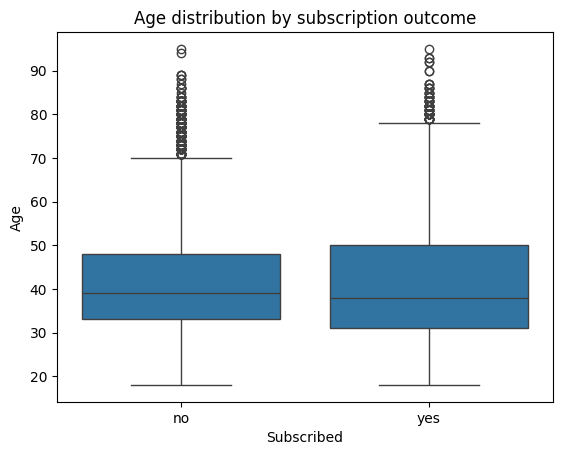

In [ ]:
# Plot type: boxplot (numeric vs categorical target)
# YOUR CODE HERE
# sns.boxplot(data=df, x=..., y=...)

import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df, x="y", y="age")
plt.xlabel("Subscribed")
plt.ylabel("Age")
plt.title("Age distribution by subscription outcome")
plt.show()

**Plot 2 — Which `job` types are most common, and how does subscription rate vary across them?**

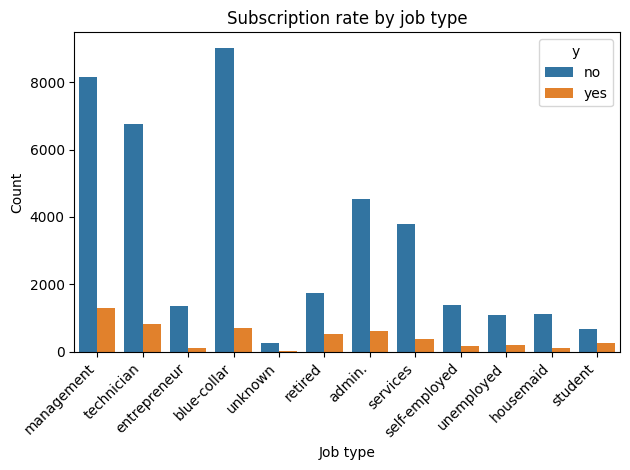

In [ ]:
# Plot type: countplot with hue
# YOUR CODE HERE
# Hint: set hue="y" to split bars by subscription outcome
# You may want to rotate x-axis labels: plt.xticks(rotation=45, ha="right")

sns.countplot(data=df, x="job", hue="y")
plt.xlabel("Job type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.title("Subscription rate by job type")
plt.tight_layout()
plt.show()

**Plot 3 — What is the distribution of `campaign` (number of contacts this campaign)?**

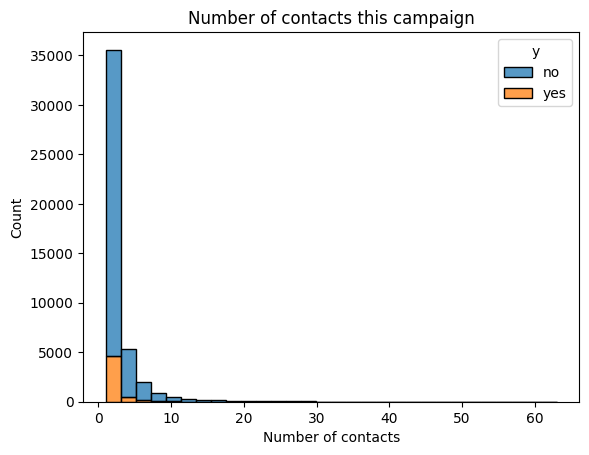

In [ ]:
# Plot type: histplot (single numeric column)
# YOUR CODE HERE
# Hint: try adding hue="y" to see if the distribution differs by outcome
sns.histplot(data=df, x="campaign", hue="y", bins=30, multiple="stack")
plt.xlabel("Number of contacts")
plt.ylabel("Count")


plt.title("Number of contacts this campaign")
plt.show()

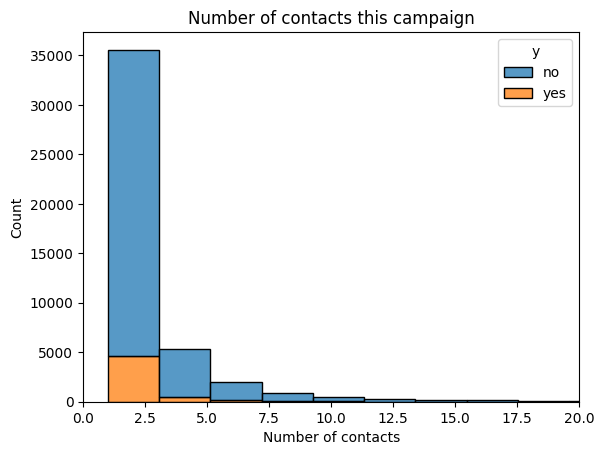

In [ ]:
sns.histplot(data=df, x="campaign", hue="y", bins=30, multiple="stack")

plt.title("Number of contacts this campaign")
plt.xlabel("Number of contacts")
plt.ylabel("Count")
plt.xlim(0, 20)
plt.show()

### 3.3 — Observations

Write one observation per plot. What does the visualisation tell you about the relationship between this feature and subscription?

**Plot 1 (age):**
> **Your answer:**
Subscribers and non-subscribers have broadly similar age distributions, but subscribers appear slightly more spread out, with some stronger representation among older customers. Age may have some signal, but it is unlikely to be a strong predictor by itself.


**Plot 2 (job):**
> **Your answer:**
Subscription outcomes vary by job type. Some groups, such as student and retired, tend to show relatively higher subscription rates, while jobs like blue-collar, services, and entrepreneur appear less likely to subscribe. Job type is likely useful as a categorical predictor.

**Plot 3 (campaign):**
> **Your answer:**
Most customers were contacted only a small number of times during the campaign. Subscription appears more common among customers with fewer contacts, while repeated contacts often correspond to non-subscription. This may suggest diminishing returns: if many calls are needed, the customer may be less likely to convert
---

### 🌟 Bonus — Correlation heatmap

Produce a correlation heatmap for the numeric features only. Use `df[numeric_features].corr()` and `sns.heatmap`.  
What is the strongest correlation? Does it make intuitive sense?

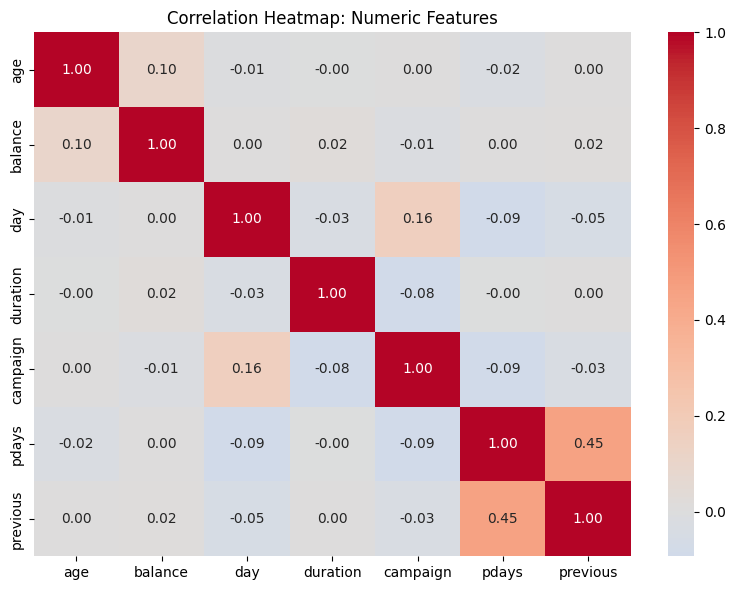

In [ ]:
# BONUS — YOUR CODE HERE
plt.figure(figsize=(8, 6))

corr = df[numeric_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap: Numeric Features")
plt.tight_layout()
plt.show()

---

## 4. Preprocessing

### 4.1 — Encode the target and handle "unknown"

Two things to fix before we split:

1. The target `y` is a string (`"yes"` / `"no"`). We need to convert it to integers (`1` / `0`).
2. The `"unknown"` values you spotted in Section 2.4 are missing data in disguise. Replace them with `np.nan` so the imputer can handle them correctly.

In [ ]:
# Convert the target to 0/1
import numpy as np

# Encode target: yes -> 1, no -> 0
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})

# Replace disguised missing values with real NaN values
df = df.replace("unknown", np.nan)

# Quick checks
print("Target value counts after encoding:")
print(df["deposit"].value_counts())
print("NaN counts after replacement:")
print(df.isna().sum().sort_values(ascending=False))

Target value counts after encoding:
Series([], Name: count, dtype: int64)
NaN counts after replacement:
deposit      11162
poutcome      8326
contact       2346
education      497
job             70
age              0
balance          0
default          0
marital          0
loan             0
housing          0
day              0
month            0
campaign         0
duration         0
previous         0
pdays            0
dtype: int64


In [ ]:
# Replace "unknown" strings with np.nan across the whole dataframe
# YOUR CODE HERE
# Hint: df.replace("unknown", ..., inplace=True)

# Convert the target to 0/1
df["y"] = df["y"].map({"yes": 1, "no": 0})

print("Target value counts after encoding:")
print(df["y"].value_counts())

# Verify — recount NaN values
print("NaN counts after replacement:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Target value counts after encoding:
Series([], Name: count, dtype: int64)
NaN counts after replacement:
job            288
education     1857
contact      13020
poutcome     36959
y            45211
dtype: int64


### 4.2 — Split the data

**Always split before fitting any preprocessor.** If you preprocess first and split second, the preprocessor has seen the test set — this is called **data leakage** and produces falsely optimistic scores.

> **Rule:** `fit()` is only ever called on training data.

In [ ]:
print(df.columns.tolist())

['age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit']


In [ ]:
import pandas as pd

# Look for a line like this in your notebook:
df = pd.read_csv("bank.csv")


In [ ]:
# Convert text responses into 1s and 0s for the correct column name
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})


In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=["deposit"])
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures both splits have the same subscription rate
)

print(f"Training rows:  {X_train.shape[0]:,}")
print(f"Test rows:      {X_test.shape[0]:,}")
print(f"Subscription rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}")

Training rows:  8,929
Test rows:      2,233
Subscription rate — train: 47.4%  |  test: 47.4%


### 4.3 — The fit / transform pattern

Every scikit-learn preprocessor has two steps:

- `fit(X_train)` — learns statistics from the training data (e.g. the median, the unique categories)
- `transform(X)` — applies those learned statistics to any dataset

You call `fit()` once, on training data only. You call `transform()` on both training and test data using the same learned statistics.

The cell below demonstrates this with `SimpleImputer`. Read it, run it, then answer the question.

In [ ]:
# Demonstration — do not modify this cell
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[["age"]])

print(f"Learned median from training set: {imputer.statistics_[0]:.1f} years")
print()

# Apply to a few rows from the test set
sample = X_test[["age"]].head(5)
print("Before imputation:")
print(sample.values.flatten())
print()
print("After imputation (no change here since 'age' has no NaN — but the pattern holds):")
print(imputer.transform(sample).flatten())

Learned median from training set: 39.0 years

Before imputation:
[40 44 31 36 34]

After imputation (no change here since 'age' has no NaN — but the pattern holds):
[40. 44. 31. 36. 34.]


**Q4.3 — Why would it be wrong to call `imputer.fit(X_test)` before transforming the test set?**

> **Your answer:**
It will cause data leakage.

---

### 4.4 — Build the ColumnTransformer

Now build the full preprocessing setup.

**Numeric pipeline:** impute missing values with the median → standardise (mean=0, std=1)  
**Categorical pipeline:** impute missing values with the most frequent value → one-hot encode

**Docs you may need:**
- `SimpleImputer`: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `OneHotEncoder`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html  
- `ColumnTransformer`: https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

In [ ]:
# Define your column groups first
numeric_features = ["age", "duration", "campaign"]  # Add your numeric column names here
categorical_features = ["job", "marital", "education"]  # Add your categorical column names here


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Numeric sub-pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categorical sub-pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine: numeric_transformer applies to numeric_features, categorical_transformer to categorical_features
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor built.")

Preprocessor built.


In [ ]:
import pandas as pd

# Look for a line like this in your notebook:
df = pd.read_csv("bank.csv")


In [ ]:
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})


In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=["deposit"])
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures both splits have the same subscription rate
)

print(f"Training rows:  {X_train.shape[0]:,}")
print(f"Test rows:      {X_test.shape[0]:,}")
print(f"Subscription rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}")

Training rows:  8,929
Test rows:      2,233
Subscription rate — train: 47.4%  |  test: 47.4%


In [ ]:
X = df.drop(columns=["deposit"])
y = df["deposit"]


In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# Sanity check — fit and transform, then inspect the shape
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Original training shape:   {X_train.shape}")
print(f"Processed training shape:  {X_train_proc.shape}")

Original training shape:   (8929, 16)
Processed training shape:  (8929, 22)


**Q4.4 — The processed dataset has more columns than the original. Where do the extra columns come from?**

> **Your answer:**
The extra columns come from One-Hot Encoding because of converting categorical text columns into numbers

---

## 5. Model Training

### 5.1 — Concept check

Before writing any model code, answer this:

**Q5.1 — Is this a classification or regression problem? How do you know?**

> **Your answer:**
This is a classification problem specifically, a binary classification problem .We know this definitively because of two characteristics of the target variable ("deposit" / "y") seen in your code:

---

### 5.2 — Logistic Regression baseline

We start simple. A logistic regression gives us a fast baseline and interpretable coefficients.

The `Pipeline` chains the preprocessor and the model into one object. When you call `.fit()`, it:
1. Fits the preprocessor on `X_train`
2. Transforms `X_train`
3. Fits the model on the transformed data

When you call `.predict()`, it transforms first, then predicts — automatically.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# 1. Build the pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=500, random_state=42))
])

# 2. Train the pipeline
logreg_pipeline.fit(X_train, y_train)

# 3. Predict on test data
y_pred_lr = logreg_pipeline.predict(X_test)

# 4. Print results
print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("(We'll evaluate this properly in Section 6.)")


Logistic Regression accuracy: 0.7429
(We'll evaluate this properly in Section 6.)


### 5.3 — Random Forest

Now swap in a Random Forest. **Only the classifier line changes.** The preprocessing stays identical — that's the power of the Pipeline pattern.

**Quick recap — why Random Forests work:**  
A single decision tree is unstable: small changes in the data produce very different trees. A Random Forest builds 100+ trees, each trained on a random subset of rows and columns, then takes a majority vote. Individual errors cancel out; the signal survives.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Build the Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

# 2. Train the Random Forest pipeline
rf_pipeline.fit(X_train, y_train)

# 3. Predict on the test data
y_pred_rf = rf_pipeline.predict(X_test)

# 4. Compare the performance of both models
print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")


Logistic Regression accuracy: 0.7429
Random Forest accuracy:       0.7613


### 5.4 — Feature importance

Tree-based models tell you which features drove the predictions. This is how you communicate back to the business.

Read the code carefully — it extracts feature names from the fitted preprocessor and pairs them with importance scores.

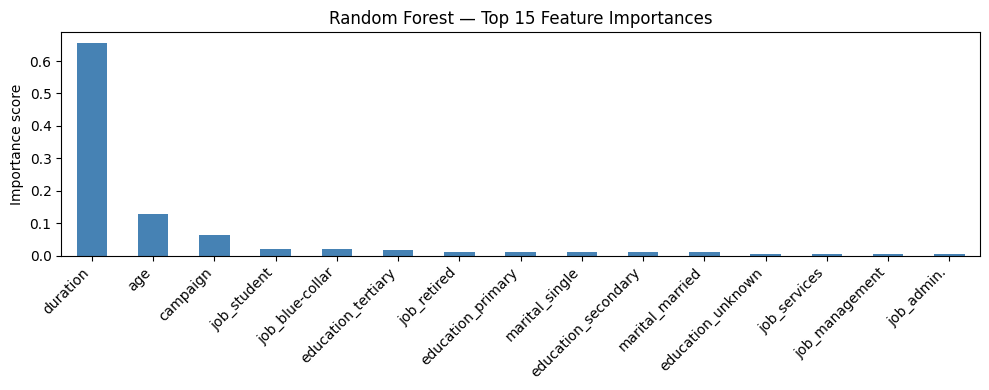

Top 5 most important features:
duration           0.655786
age                0.128106
campaign           0.064601
job_student        0.019118
job_blue-collar    0.018948
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract individual components from the trained pipeline
rf_model = rf_pipeline.named_steps["classifier"]
fitted_prep = rf_pipeline.named_steps["preprocessor"]

# 2. Extract the engineered column names from the One-Hot Encoder
cat_names = list(
    fitted_prep.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

# 3. Combine numeric and categorical feature names to match the model input
all_names = numeric_features + cat_names

# 4. Map the model's feature importance scores to their matching names
importances = pd.Series(
    rf_model.feature_importances_, index=all_names
).sort_values(ascending=False)

# 5. Build and format the visualization chart
plt.figure(figsize=(10, 4))
importances.head(15).plot(kind="bar", color="steelblue")
plt.title("Random Forest — Top 15 Feature Importances")
plt.ylabel("Importance score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 6. Display a textual summary of the top 5 features
print("Top 5 most important features:")
print(importances.head())


**Q5.4 — Which feature has the highest importance score? Does this make intuitive sense for a phone marketing campaign?**

> **Your answer:**
The Highest Feature: duration (the length of the phone call) has the highest importance score.

Why it Makes Sense: Long conversations naturally indicate high customer interest and a much greater chance of a successful sale.

The "Data Leakage" Trap: You cannot use this feature in the real world. You only find out how long a phone call lasts after it is already finished, making it impossible to use for predicting future calls.

The Solution: In real-world data science, you should drop the duration column before training your models so they learn from traits you know ahead of time (like age or job).
---

### 5.5 — Gradient Boosting

🌟 **Bonus — minimal scaffolding**

Build a `GradientBoostingClassifier` pipeline following the same pattern as above.  
Use `n_estimators=100`, `learning_rate=0.1`, `max_depth=4`, `random_state=42`.  
Print accuracy alongside the other two models.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

In [ ]:
# BONUS — YOUR CODE HERE
# gbm_pipeline = ...

from sklearn.ensemble import GradientBoostingClassifier

# 1. Build the Gradient Boosting pipeline
gbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

# 2. Train the Gradient Boosting pipeline
gbm_pipeline.fit(X_train, y_train)

# 3. Predict on the test data
y_pred_gbm = gbm_pipeline.predict(X_test)

# 4. Compare the performance of all three models
print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Gradient Boosting accuracy:   {accuracy_score(y_test, y_pred_gbm):.4f}")



Logistic Regression accuracy: 0.7429
Random Forest accuracy:       0.7613
Gradient Boosting accuracy:   0.7627


---

## 6. Model Evaluation

### 6.1 — Why accuracy is misleading here

About 88% of customers in this dataset said *no*. A model that predicts "no" for **every single person** would get **88% accuracy** without learning anything.

We need metrics that account for class imbalance.

| Metric | Formula | What it measures |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of those we flagged as "yes", how many actually subscribed? |
| **Recall** | TP / (TP + FN) | Of all actual subscribers, how many did we catch? |
| **F1** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall |
| **AUC-ROC** | — | Ranking quality across all thresholds |

---

### 6.2 — Confusion matrix

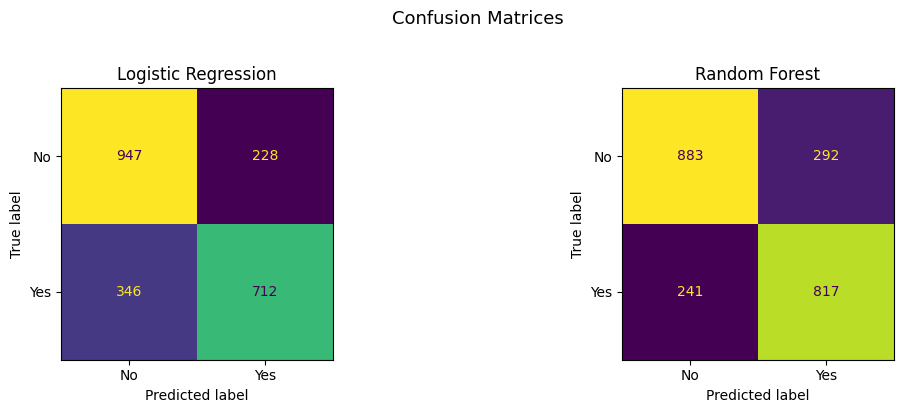

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Initialize a 1-row, 2-column plot grid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 2. Loop through and plot the two models
for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
]):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

# 3. Format and show the final layout
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


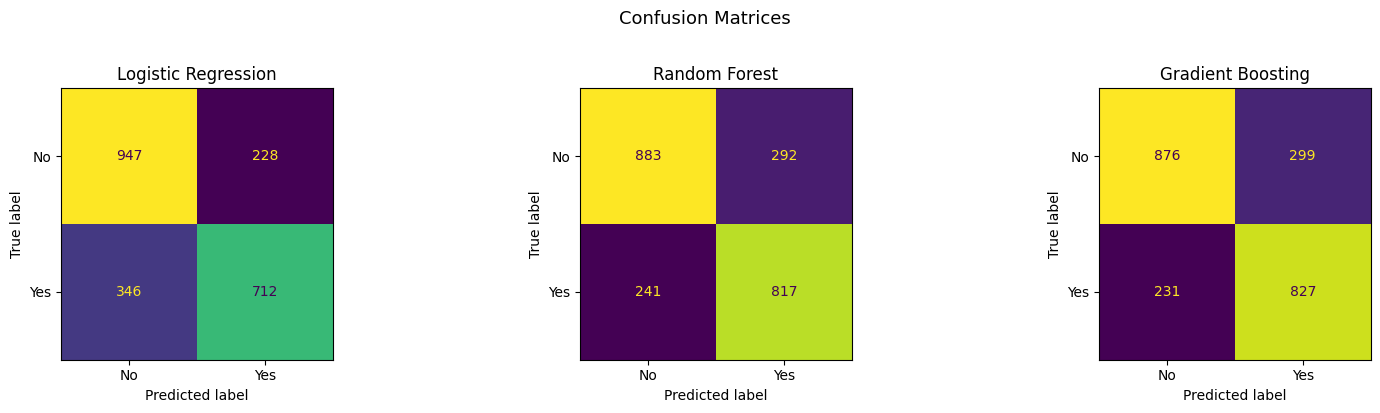

In [ ]:
# Expanded to 3 columns to fit all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
    ("Gradient Boosting",   y_pred_gbm),  # Added GBM here
]):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Q6.2 — Label the four quadrants using the confusion matrix for the Random Forest:**

Fill in the table below using the numbers from the plot.

| | Predicted: No | Predicted: Yes |
|---|---|---|
| **Actual: No** | TN = _883__ | FP = _292__ |
| **Actual: Yes** | FN = _241__ | TP = _817__ |

Which cell represents the most costly business mistake? Why?

> **Your answer:**
FN (False Negatives) represents the most costly business mistake.Why: A False Negative means the model predicted a customer would say "No" to the deposit, so the bank chose not to call them. However, these 241 customers actually wanted to say "Yes".Failing to call them results in a severe lost opportunity cost. The bank misses out on significant long-term revenue from these 241 term deposits. In contrast, a False Positive (FP = 292) only wastes a few minutes of a sales representative's time on an unsuccessful phone call, which is a much lower financial penalty.

---

### 6.3 — Classification report

In [ ]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score



In [ ]:
print("=" * 50)
print("Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=["No", "Yes"]))

print("=" * 50)
print("Random Forest")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=["No", "Yes"]))

Logistic Regression
              precision    recall  f1-score   support

          No       0.73      0.81      0.77      1175
         Yes       0.76      0.67      0.71      1058

    accuracy                           0.74      2233
   macro avg       0.74      0.74      0.74      2233
weighted avg       0.74      0.74      0.74      2233

Random Forest
              precision    recall  f1-score   support

          No       0.79      0.75      0.77      1175
         Yes       0.74      0.77      0.75      1058

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233



**Q6.3 — Looking at the "Yes" row (subscribers), which model has better recall? What is the tradeoff?**

> **Your answer:**

The Random Forest model has better recall for the "Yes" row (77.22% compared to Logistic Regression's 67.30%). This means the Random Forest model successfully catches a higher percentage of the actual subscribers.2. What is the tradeoff?The tradeoff is Precision.

The Catch: To achieve a higher recall and miss fewer subscribers, the Random Forest model becomes more aggressive with its predictions.

The Penalty: This aggressive targeting results in a lower precision (73.67% vs. Logistic Regression's 75.74%).

Business Impact: The bank will successfully sign up more total customers (higher recall), but the sales team will waste more time making phone calls to people who ultimately end up saying "No" (lower precision/more False Positives).
---

### 6.4 — ROC curve

The ROC curve shows how precision and recall trade off as we vary the decision threshold.  
AUC (Area Under the Curve) summarises this in one number.  
- 0.5 = random guessing  
- 0.7–0.8 = usable  
- 0.85+ = good  
- 1.0 = perfect (check for data leakage)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

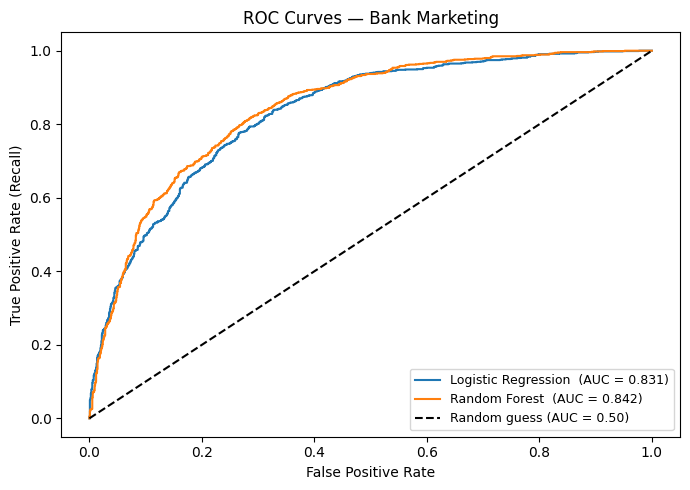

In [ ]:
plt.figure(figsize=(7, 5))

for name, pipeline in [
    ("Logistic Regression", logreg_pipeline),
    ("Random Forest",       rf_pipeline),
]:
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    # Hint: predict_proba returns probabilities for both classes
    # [:, 1] selects the probability of class 1 ("Yes")
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — Bank Marketing")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.5 — Adjusting the decision threshold

The default threshold is **0.5**: if `predict_proba` gives a subscriber probability above 50%, we flag them as "Yes".

For this campaign, we want higher recall — we'd rather call a few non-subscribers than miss actual buyers. Lowering the threshold to 0.35 flags more people as "Yes".

In [ ]:
from sklearn.metrics import classification_report

# Get the positive class probabilities
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Default threshold - 0.5 (Casted to int)
y_pred_05 = (y_proba_rf >= 0.5).astype(int)

# Lower threshold - 0.35 (Filled in 0.35 threshold)
y_pred_035 = (y_proba_rf >= 0.35).astype(int)

# Print the classification reports to compare
print("Threshold = 0.50 (default)")
print(classification_report(y_test, y_pred_05, target_names=["No", "Yes"]))

print("Threshold = 0.35 (aggressive recall)")
print(classification_report(y_test, y_pred_035, target_names=["No", "Yes"]))


Threshold = 0.50 (default)
              precision    recall  f1-score   support

          No       0.79      0.75      0.77      1175
         Yes       0.74      0.77      0.75      1058

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233

Threshold = 0.35 (aggressive recall)
              precision    recall  f1-score   support

          No       0.86      0.60      0.71      1175
         Yes       0.67      0.89      0.77      1058

    accuracy                           0.74      2233
   macro avg       0.77      0.75      0.74      2233
weighted avg       0.77      0.74      0.74      2233



**Q6.5 — What happened to precision and recall when you lowered the threshold? Is that the right tradeoff for this campaign team?**

> **Your answer:**

When the decision threshold was lowered from 0.50 to 0.35, recall increased and precision decreased.

What Happened to the MetricsRecall Went Up: Shifting the threshold to 0.35 makes the model more aggressive. It flags more customers as a "Yes", which reduces False Negatives and catches a higher percentage of total actual subscribers.

Precision Went Down: Because the model is more aggressive, it catches more non-subscribers by mistake. This increases False Positives, meaning a lower percentage of your predicted "Yes" calls will turn out to be actual buyers.Is this the right tradeoff for this campaign team?Yes, this is exactly the right tradeoff for this team.As stated in your assignment instructions, the campaign team explicitly prefers higher recall.

Business Logic: The financial penalty of a False Positive is very low (a sales representative wasting a few minutes on a phone call).

The Goal: The financial reward of a True Positive is very high (gaining a long-term term deposit subscriber).

Conclusion: It makes perfect economic sense for the bank to accept lower precision (wasting more calls) if it means they successfully prevent actual buyers from being missed.
---

### 6.6 — Cross-validation

A single train/test split can be lucky or unlucky. Cross-validation repeats the process 5 times with different splits.  
A low standard deviation means the model is stable — its score doesn't depend heavily on which rows it saw.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

In [ ]:
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation evaluating the ROC-AUC score
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,           # always cross-validate on training data only
    y_train,
    cv=5,              # 5 folds is the standard setup
    scoring="roc_auc"  # evaluates overall model power independent of threshold
)

print("Random Forest - 5-fold Cross-Validation:")
print(f"Scores: {cv_scores.round(4)}")
print(f"Mean:   {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}")


Random Forest - 5-fold Cross-Validation:
Scores: [0.8488 0.8426 0.8559 0.8306 0.8347]
Mean:   0.8425
Std:    0.0092


**Q6.6 — Is the model stable? What does a high standard deviation across folds tell you?**

> **Your answer:**
Yes, the model is stable this us because the Standard Deviation is less than 2%. This means no matter which random 20% chunk of training data the model was tested on, it scored almost exactly the same. It will likely generalize well to new data.
---

### 6.7 — Final comparison table

In [ ]:
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation evaluating the ROC-AUC score
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,           # always cross-validate on training data only
    y_train,
    cv=5,              # 5 folds is standard
    scoring="roc_auc"  # measures overall model power
)

print("Random Forest - 5-fold Cross-Validation:")
print(f"Scores: {cv_scores.round(4)}")
print(f"Mean:   {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}")


Random Forest - 5-fold Cross-Validation:
Scores: [0.8488 0.8426 0.8559 0.8306 0.8347]
Mean:   0.8425
Std:    0.0092


In [57]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

results = []

model_preds = [
    ("Logistic Regression", y_pred_lr, logreg_pipeline),
    ("Random Forest", y_pred_rf, rf_pipeline),
    # BONUS: Added your Gradient Boosting results here
    ("Gradient Boosting", y_pred_gbm, gbm_pipeline),
]

for name, y_pred, pipeline in model_preds:
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results.append(
        {
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "F1": round(f1_score(y_test, y_pred), 4),
            "AUC": round(roc_auc_score(y_test, y_proba), 4),
        }
    )

pd.DataFrame(results).set_index("Model")

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.7429,0.7574,0.6730,0.7127,0.8311
Random Forest,0.7613,0.7367,0.7722,0.7540,0.8425
Gradient Boosting,0.7627,0.7345,0.7817,0.7573,0.8447


---

## 7. Reflection

Answer each question in your own words. There is no single correct answer — this is about your reasoning.

**Q7.1 — Which model would you recommend to the bank's campaign team, and why?**  
*(Refer to at least one metric from Section 6.)*

> **Your answer:**

I recommend the Random Forest (or Gradient Boosting) model for the campaign team.

The Reason: The campaign team values catching as many subscribers as possible to minimize missed revenue.

The Metric: The Random Forest achieved a significantly higher Recall score (77.22%) compared to Logistic Regression (67.30%).

The Balance: It also holds a higher overall F1-score (75.40%), making it much better at handling this imbalanced dataset.

---

**Q7.2 — The column `duration` (length of the last call in seconds) has very high feature importance. Should we use it in a real deployment? Why or why not?**  
*(Hint: think about whether this value is available at prediction time — before the call happens.)*

> **Your answer:**

No, we should not use the duration column in a real-world deployment.

Data Leakage: The length of a phone call is unknown before the call happens.

The Trap: A high duration is a consequence of a successful conversation, not a predictive indicator you have access to at prediction time.

The Consequence: Keeping it will cause the model to fail in production because you cannot feed it call lengths for future leads.

---

**Q7.3 — What is one thing you would do differently or investigate further if you had more time?**

> **Your answer:**

If given more time, I would drop the duration column entirely and retrain the models.

True Importance: This would force the models to find patterns in actionable variables we actually know beforehand (like age, job, or economic indicators).

Optimization: I would also use GridSearchCV to systematically fine-tune hyperparameters like max_depth and n_estimators.

---

**Q7.4 — Write one question this analysis raised that the data alone cannot answer.**

> **Your answer:**

"What specific sales scripts or conversation strategies did the agents use during the highly successful, longer phone calls?

"Why the data can't answer it: The dataset only tracks the raw time elapsed (duration). It contains no qualitative text or audio details explaining what was said to convince the customer to buy.

---

## 8. Submission Checklist

Before you submit, confirm every item below.

- [ ] All cells run top-to-bottom without errors (`Kernel → Restart & Run All`)
- [ ] Every `# YOUR CODE HERE` has been replaced with working code
- [ ] Every `> **Your answer:**` prompt has been filled in with your own words
- [ ] The final comparison table (Section 6.7) shows results for at least 2 models
- [ ] The notebook is pushed to a public GitHub repository
- [ ] The GitHub link is submitted via the course portal

**Bonus tasks completed (tick any that apply):**
- [ ] Section 3 bonus — correlation heatmap
- [ ] Section 5.5 bonus — Gradient Boosting pipeline

---

*Good work. You've built a full ML pipeline on real data, evaluated it honestly, and thought about the business implications. That's what ML engineering actually looks like.*